# XGBoost

The data was preprocessed and an XGBoost model was fit to it:
- Numerical features scaled using StandardScaler
- Categrorical features one hot encoded
- GridSearchCV used to tune model hyperparameters

The **key results** were:
- **64% Precision for Class 1:**
  - Of all the customers that the model predicted would subscribe, 64% actually did.
- **44% Recall for Class 1:**
  - Of all the customers that subscribed, the model identified 44% of them.
- **52% F1 Score for Class 1:**
  - The model has a moderate balance of precision and recall.

In [21]:
# change the directory to the repository
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\Data\Apziva\uyBvjh22fVpcb3UX")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\Data\\Apziva\\uyBvjh22fVpcb3UX'

In [22]:
# import all the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [23]:
# set random state for the notebook
random_state = 42
np.random.seed(random_state)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:
{'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 50, 'classifier__subsample': 0.8, 'smote__sampling_strategy': 0.5}
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      7421
           1       0.44      0.66      0.53       579

    accuracy                           0.91      8000
   macro avg       0.70      0.80      0.74      8000
weighted avg       0.93      0.91      0.92      8000



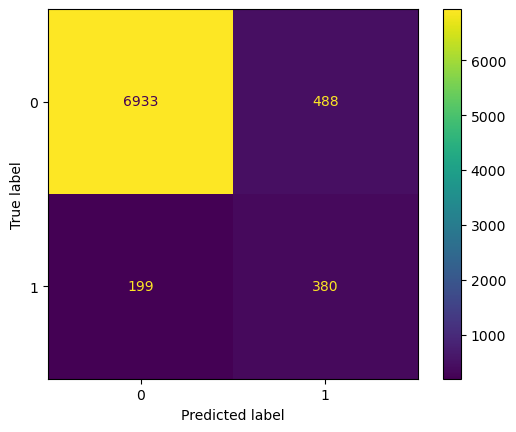

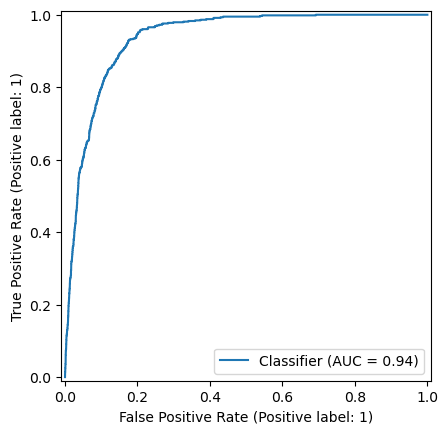

In [24]:
# import the data
data = pd.read_csv("data/processed/processed_data.csv")

# split the data into x and y
x = data[['age_group', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_group', 'campaign', 'duration', 'quarter']]
y = data['target']

# split the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_state, stratify=y)

# identify numerical and categorical features
cat_features = x.select_dtypes(include='object').columns
num_features = x.select_dtypes(include='number').columns

# preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), cat_features),
        ('num', StandardScaler(), num_features)
    ])

# modelling pipeline
xgb_pipe = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=random_state)),
        ('classifier', XGBClassifier(random_state=random_state))
    ])

# hyperparameter options to try
param_grid = {
    'smote__sampling_strategy': [0.2, 0.5],
    'classifier__n_estimators': [50],
    'classifier__max_depth': [2, 5, 10],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__learning_rate': [0.01, 0.1]
}

# modeling grid
grid = GridSearchCV(
    xgb_pipe, 
    param_grid, 
    cv=5,
    scoring='f1',
    n_jobs=2,
    verbose=1
)

# fitting grid to data, finding the best model
grid.fit(x_train, y_train)
best_model = grid.best_estimator_
best_params = grid.best_params_

# making predictions using the best model
y_pred = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]

# print the best parameters
print('Best Parameters:')
print(best_params)

# show classification report containing detailed metrics
print(classification_report(y_test, y_pred))

# show confusion matrix of predicted data vs actual
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# display ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

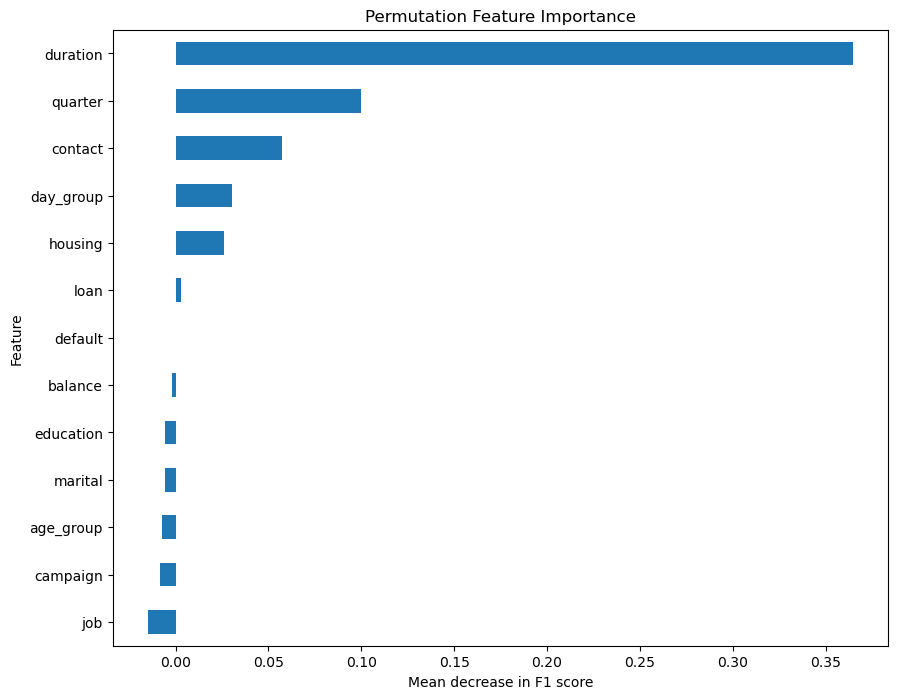

In [25]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    x_test,
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=random_state,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    'feature': x_test.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

feature_importance.sort_values('importance').plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(10, 8),
    legend=False
)

plt.xlabel('Mean decrease in F1 score')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance')
plt.show()

In [26]:
feature_importance

,feature,importance,std
11,duration,0.364553,0.009930
12,quarter,0.099701,0.007350
8,contact,0.057489,0.008443
9,day_group,0.030491,0.004104
6,housing,0.026004,0.004010
7,loan,0.003032,0.004202
4,default,0.000000,0.000000
5,balance,-0.001840,0.003362
3,education,-0.005914,0.002680
2,marital,-0.005944,0.003786
